# Synthetic Bayesian Decoder Check

Simulate 10 place cells with Gaussian place fields evenly distributed on a 1D linear track, generate Poisson spikes while an animal runs repeated laps, and run the leave-one-lap-out Bayesian decoder.

This is a controlled smoke test: because the generative model matches the decoder assumptions reasonably well, decoded position should track actual position and errors should be small compared with the full track length.

In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'src' / 'placefields').is_dir():
    repo_root = repo_root.parent
if not (repo_root / 'src' / 'placefields').is_dir():
    raise RuntimeError('Could not find repository root containing src/placefields')

sys.path.insert(0, str(repo_root / 'src'))

from placefields import BayesianDecoderConfig, TrialInfo, decode_bayesian_position_from_trials

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

repo_root

WindowsPath('C:/Users/tadse/OneDrive/Documenti/GitHub/CA1-cellclass')

In [9]:
# Simulation parameters
RNG_SEED = 42
TRACK_LENGTH_CM = 100.0
N_NEURONS = 10
N_LAPS = 11
FREQ_HZ = 1000.0
LAP_DURATION_S = 10.0

# Place-field parameters
BASELINE_HZ = 0.05
PEAK_HZ = 18.0
FIELD_SIGMA_CM = 8.0

# Decoder parameters
TAU_S = 0.150
BIN_SIZE_CM = 2.0
SMOOTH_SIGMA_BINS = 1.2
MIN_SPEED = 0.0
DECODE_GROUPBY = 'condway'

rng = np.random.default_rng(RNG_SEED)

In [10]:
samples_per_lap = int(round(LAP_DURATION_S * FREQ_HZ))
n_samples = samples_per_lap * N_LAPS
dt = 1.0 / FREQ_HZ

# Repeated forward laps from 0 to L. The small endpoint offset avoids edge-bin ambiguity.
x_one_lap = np.linspace(0.001, TRACK_LENGTH_CM - 0.001, samples_per_lap, dtype=np.float64)
position_x = np.tile(x_one_lap, N_LAPS)
speed = np.full(n_samples, TRACK_LENGTH_CM / LAP_DURATION_S, dtype=np.float64)

cell_ids = np.arange(1, N_NEURONS + 1, dtype=np.int64)
place_centers = np.linspace(
    TRACK_LENGTH_CM / (N_NEURONS + 1),
    TRACK_LENGTH_CM * N_NEURONS / (N_NEURONS + 1),
    N_NEURONS,
)

rate_ut = BASELINE_HZ + PEAK_HZ * np.exp(
    -0.5 * ((position_x[None, :] - place_centers[:, None]) / FIELD_SIGMA_CM) ** 2
)
spike_counts_ut = rng.poisson(rate_ut * dt)

spike_indices = []
spike_cell_ids = []
for u, cid in enumerate(cell_ids):
    idx = np.repeat(np.arange(n_samples, dtype=np.int64), spike_counts_ut[u].astype(np.int64))
    spike_indices.append(idx)
    spike_cell_ids.append(np.full(idx.size, int(cid), dtype=np.int64))

spike_indices_0b = np.concatenate(spike_indices) if spike_indices else np.array([], dtype=np.int64)
spike_cell_ids = np.concatenate(spike_cell_ids) if spike_cell_ids else np.array([], dtype=np.int64)
order = np.argsort(spike_indices_0b, kind='stable')
spike_indices_0b = spike_indices_0b[order]
spike_cell_ids = spike_cell_ids[order]

trials = [
    TrialInfo(
        trial_index=lap,
        cond=1,
        wb='W',
        condway=1,
        start_idx_0b=lap * samples_per_lap,
        stop_idx_0b_exclusive=(lap + 1) * samples_per_lap,
    )
    for lap in range(N_LAPS)
]
xbin_edges = np.arange(0.0, TRACK_LENGTH_CM + BIN_SIZE_CM, BIN_SIZE_CM, dtype=np.float64)

print('samples:', n_samples)
print('spikes:', spike_indices_0b.size)
print('mean firing rates Hz:', np.round(spike_counts_ut.sum(axis=1) / (n_samples / FREQ_HZ), 2))

samples: 110000
spikes: 3842
mean firing rates Hz: [3.3  3.52 3.26 3.45 3.67 3.74 3.55 3.85 3.62 2.96]


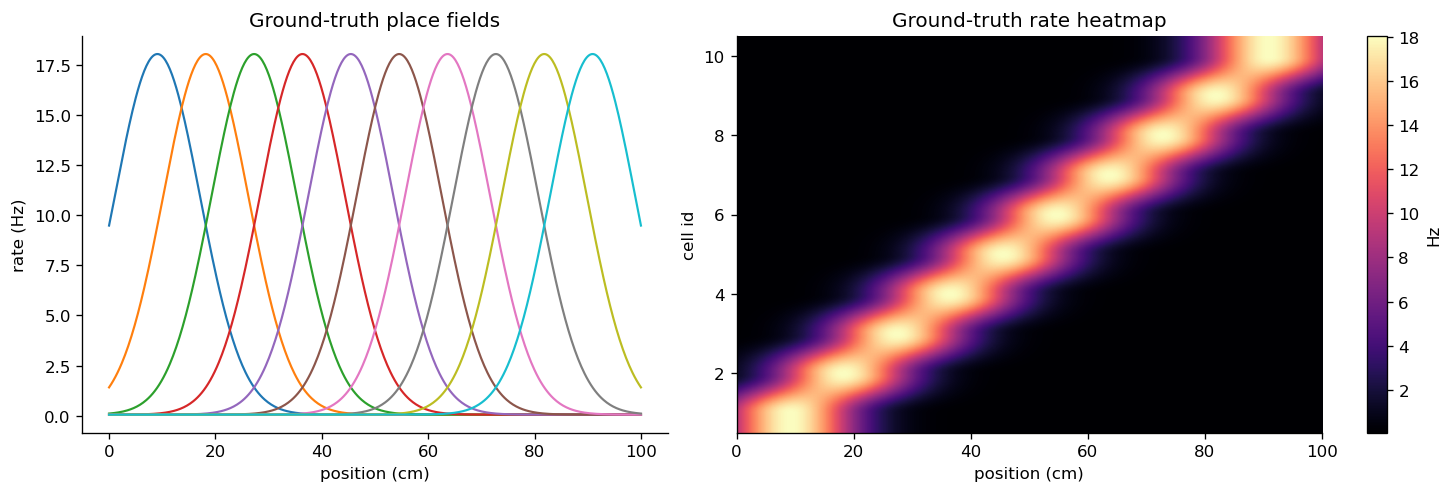

In [11]:
x_plot = np.linspace(0, TRACK_LENGTH_CM, 500)
true_rate_ux = BASELINE_HZ + PEAK_HZ * np.exp(
    -0.5 * ((x_plot[None, :] - place_centers[:, None]) / FIELD_SIGMA_CM) ** 2
)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for u, cid in enumerate(cell_ids):
    axs[0].plot(x_plot, true_rate_ux[u], lw=1.3, label=f'cell {cid}')
axs[0].set_title('Ground-truth place fields')
axs[0].set_xlabel('position (cm)')
axs[0].set_ylabel('rate (Hz)')

im = axs[1].imshow(
    true_rate_ux,
    origin='lower',
    aspect='auto',
    extent=[0, TRACK_LENGTH_CM, 0.5, N_NEURONS + 0.5],
    cmap='magma',
)
axs[1].set_title('Ground-truth rate heatmap')
axs[1].set_xlabel('position (cm)')
axs[1].set_ylabel('cell id')
fig.colorbar(im, ax=axs[1], label='Hz')
plt.show()

In [12]:
cfg = BayesianDecoderConfig(
    freq_hz=FREQ_HZ,
    tau_s=TAU_S,
    bin_size_cm=BIN_SIZE_CM,
    min_speed=MIN_SPEED,
    smooth_sigma_bins=SMOOTH_SIGMA_BINS,
    xbin_rem=0,
    min_valid_window_fraction=0.5,
    rate_floor_hz=1e-12,
    decode_groupby=DECODE_GROUPBY,
)

result = decode_bayesian_position_from_trials(
    position_x=position_x,
    spike_indices_0b=spike_indices_0b,
    spike_cell_ids=spike_cell_ids,
    cell_ids=cell_ids,
    trials=trials,
    xbin_edges=xbin_edges,
    cfg=cfg,
    speed=speed,
)

decode_df = pd.DataFrame(
    {
        'trial_index': result.trial_index_w,
        'window_start': result.window_start_w,
        'window_stop': result.window_stop_w,
        'window_mid_s': 0.5 * (result.window_start_w + result.window_stop_w) / FREQ_HZ,
        'actual_x': result.actual_x_w,
        'decoded_x': result.decoded_x_w,
        'error_cm': result.error_cm_w,
        'prob_actual': result.prob_actual_w,
        'n_spikes': result.n_spikes_w,
        'n_train_laps': result.n_train_laps_w,
    }
)

print('decoded windows:', len(decode_df))
print('posterior row-sum range:', np.sum(result.posterior_wx, axis=1).min(), np.sum(result.posterior_wx, axis=1).max())
display(decode_df[['error_cm', 'prob_actual', 'n_spikes']].describe())

decoded windows: 726
posterior row-sum range: 0.9999999999999997 1.0000000000000004


,error_cm,prob_actual,n_spikes
count,726.000000,7.260000e+02,726.000000
mean,4.988254,1.475692e-01,5.275482
std,11.228215,7.759124e-02,2.569021
min,0.246740,3.212663e-13,0.000000
25%,1.250820,9.329043e-02,3.000000
50%,2.749500,1.500782e-01,5.000000
75%,5.123330,1.994769e-01,7.000000
max,98.253940,3.873448e-01,14.000000


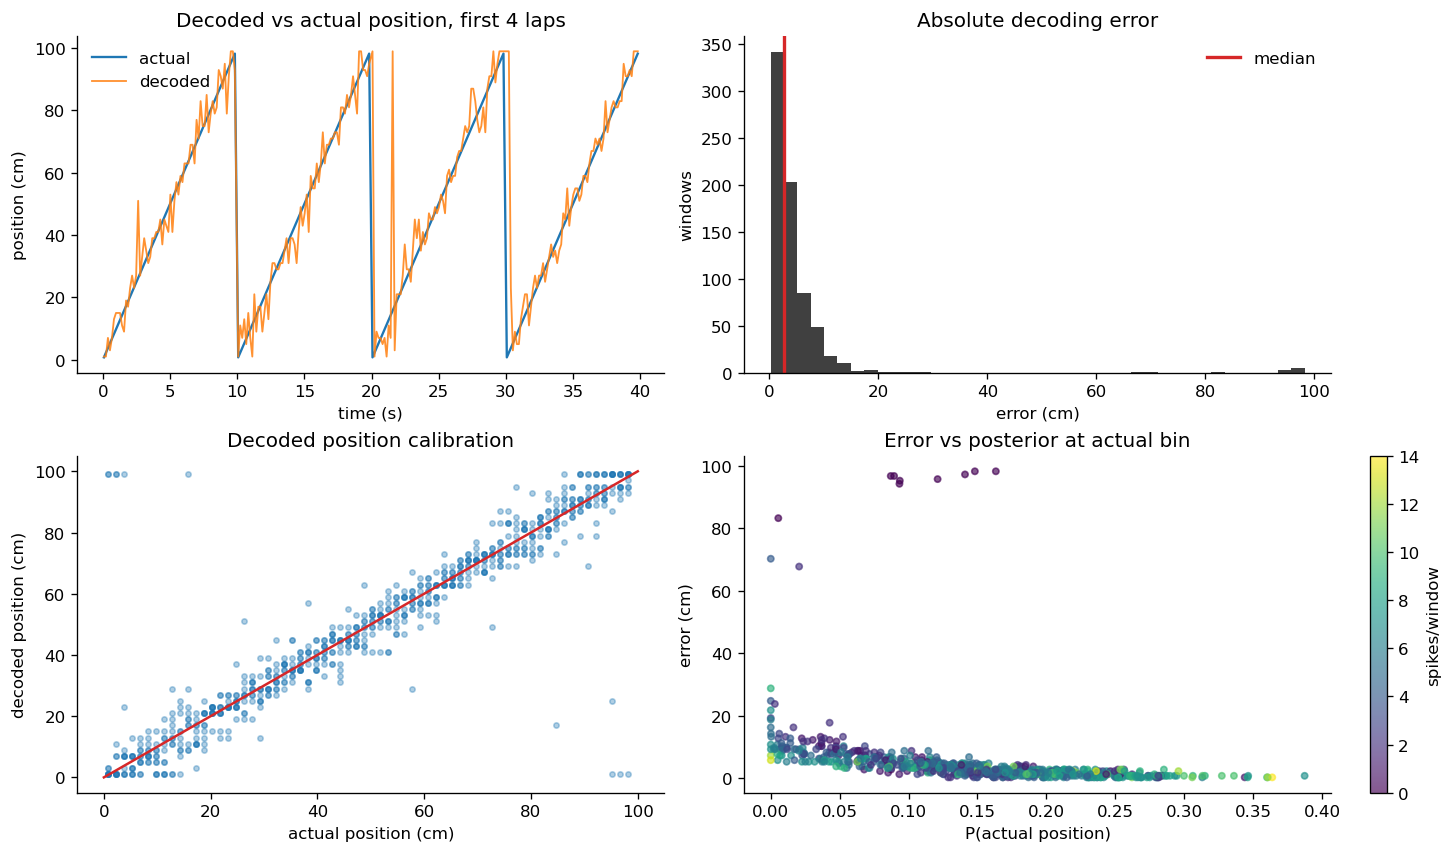

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

first_laps = decode_df[decode_df['trial_index'] < 4]
axs[0, 0].plot(first_laps['window_mid_s'], first_laps['actual_x'], label='actual', lw=1.4)
axs[0, 0].plot(first_laps['window_mid_s'], first_laps['decoded_x'], label='decoded', lw=1.1, alpha=0.85)
axs[0, 0].set_title('Decoded vs actual position, first 4 laps')
axs[0, 0].set_xlabel('time (s)')
axs[0, 0].set_ylabel('position (cm)')
axs[0, 0].legend(frameon=False)

axs[0, 1].hist(decode_df['error_cm'], bins=40, color='0.25')
axs[0, 1].axvline(decode_df['error_cm'].median(), color='tab:red', lw=2, label='median')
axs[0, 1].set_title('Absolute decoding error')
axs[0, 1].set_xlabel('error (cm)')
axs[0, 1].set_ylabel('windows')
axs[0, 1].legend(frameon=False)

axs[1, 0].scatter(decode_df['actual_x'], decode_df['decoded_x'], s=10, alpha=0.35)
axs[1, 0].plot([0, TRACK_LENGTH_CM], [0, TRACK_LENGTH_CM], color='tab:red', lw=1.5)
axs[1, 0].set_title('Decoded position calibration')
axs[1, 0].set_xlabel('actual position (cm)')
axs[1, 0].set_ylabel('decoded position (cm)')

sc = axs[1, 1].scatter(
    decode_df['prob_actual'],
    decode_df['error_cm'],
    c=decode_df['n_spikes'],
    s=14,
    alpha=0.65,
    cmap='viridis',
)
axs[1, 1].set_title('Error vs posterior at actual bin')
axs[1, 1].set_xlabel('P(actual position)')
axs[1, 1].set_ylabel('error (cm)')
fig.colorbar(sc, ax=axs[1, 1], label='spikes/window')

plt.show()

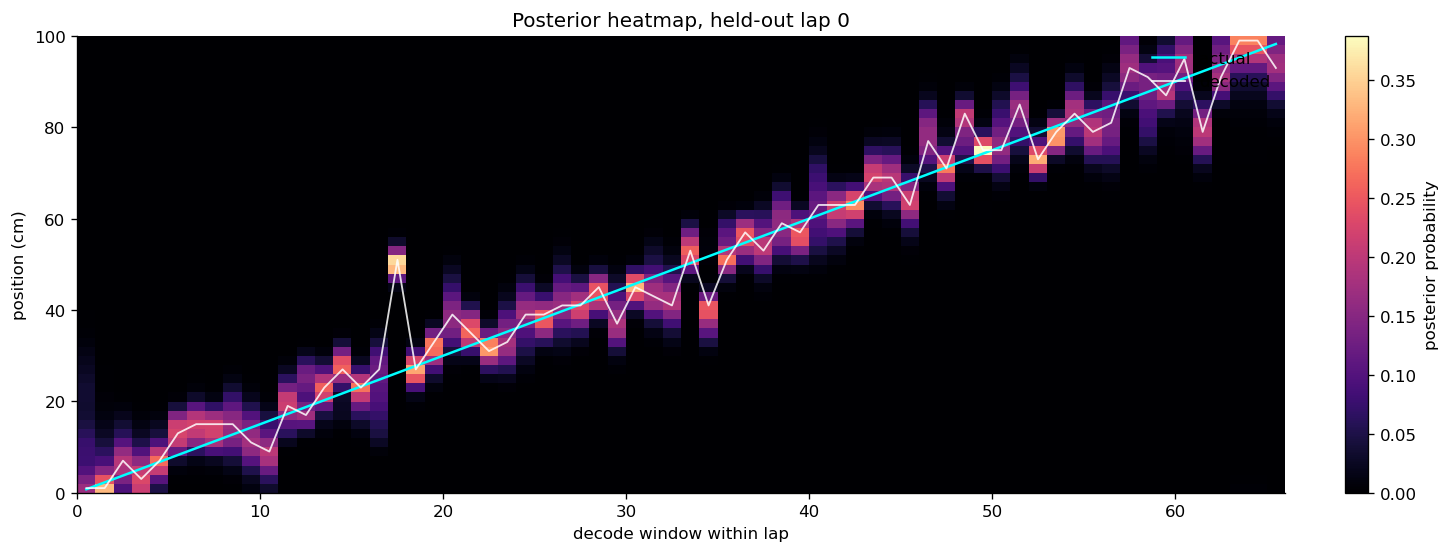

In [14]:
example_trial = int(decode_df.groupby('trial_index').size().idxmax())
idx = np.flatnonzero(result.trial_index_w == example_trial)
posterior = result.posterior_wx[idx].T
window_axis = np.arange(idx.size) + 0.5

fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
im = ax.imshow(
    posterior,
    origin='lower',
    aspect='auto',
    interpolation='nearest',
    extent=[0, idx.size, result.xbin_edges[0], result.xbin_edges[-1]],
    cmap='magma',
)
ax.plot(window_axis, result.actual_x_w[idx], color='cyan', lw=1.5, label='actual')
ax.plot(window_axis, result.decoded_x_w[idx], color='white', lw=1.1, alpha=0.85, label='decoded')
ax.set_title(f'Posterior heatmap, held-out lap {example_trial}')
ax.set_xlabel('decode window within lap')
ax.set_ylabel('position (cm)')
ax.legend(frameon=False, loc='upper right')
fig.colorbar(im, ax=ax, label='posterior probability')
plt.show()